# RL Gaming

---

## Setup

In [ ]:
from pathlib import Path

from custom_callback import CustomCallback
from env_optimiser import EnvOptimiser
from feature_extractor import MinigridFeaturesExtractor
from levels_utils import (
    bar_plot_levels_success_rate,
    display_all_levels,
    display_procedural_levels,
    evaluate_levels_with_ppo,
    evaluate_levels_with_recurrent_ppo,
)
from minigrid.wrappers import ImgObsWrapper, OneHotPartialObsWrapper
from minigrid_levels_env import MiniGridLevelsEnv
from model_utils import (
    run_model_on_level,
    run_model_on_procedural,
)
from plot_utils import plot_training_results
from procedural_level import ProceduralLevel
from sb3_contrib import RecurrentPPO
from stable_baselines3 import PPO

PPO_MODEL_PATH = next(Path("../../data/ppo/").glob("*.zip"), None)
# RECURRENT_PPO_MODEL_PATH = next(Path("../../data/rppo/").glob("*.zip"), None)
RECURRENT_PPO_MODEL_PATH_2 = next(Path("../../data/rppo_2/").glob("*.zip"), None)

---

## Environment

### Random training levels

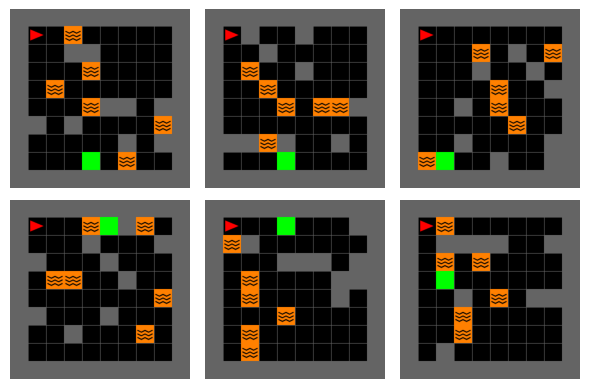

In [2]:
display_procedural_levels(n_levels=6, max_cols=3)

### Custom testing levels

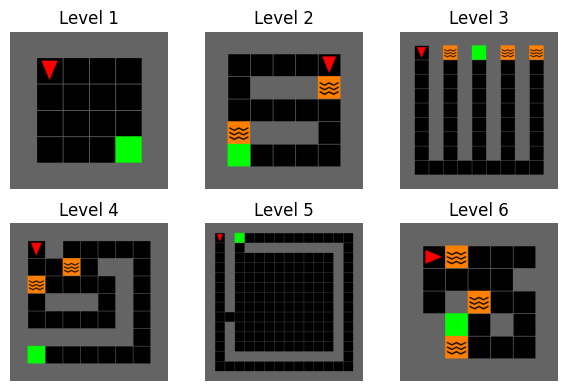

In [3]:
display_all_levels(max_cols=3)

---

## PPO

### Training

In [4]:
n_envs = 8
n_timesteps = 5_000
freq = 100
eval_freq = max(freq // n_envs, 1)

save_dir = Path("../../models/")
save_dir.mkdir(parents=True, exist_ok=True)

env = MiniGridLevelsEnv(level_id=1)
optimiser = EnvOptimiser(env=env, n_envs=n_envs, wrapper_cls=[ImgObsWrapper], save_dir=save_dir)
vec_env_train = optimiser.build_vec_env()
policy_kwargs = {
    "features_extractor_class": MinigridFeaturesExtractor,
    "features_extractor_kwargs": {"features_dim": 128},
}
model_dir = optimiser.file_path.parent
callback = CustomCallback(check_freq=eval_freq, save_dir=model_dir, verbose=0)
model = PPO(policy="CnnPolicy", env=vec_env_train, policy_kwargs=policy_kwargs)
model.learn(total_timesteps=n_timesteps, callback=callback, progress_bar=True)

Output()

### Plots

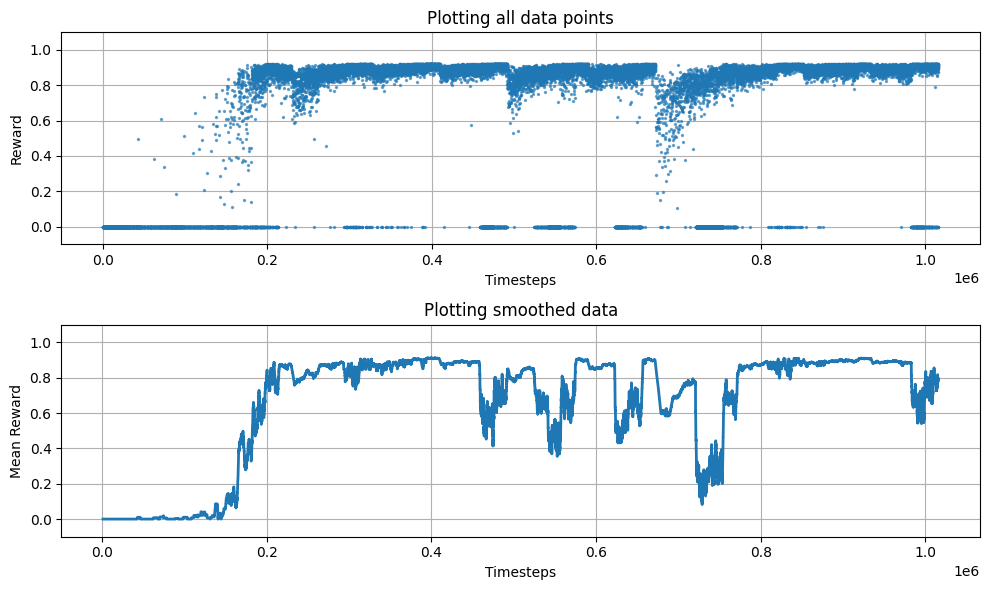

In [4]:
plot_training_results(log_dir=PPO_MODEL_PATH.parent)

### Testing

Running level 1 with PPO model...
Running level 2 with PPO model...
Running level 3 with PPO model...
Running level 4 with PPO model...
Running level 5 with PPO model...
Running level 6 with PPO model...


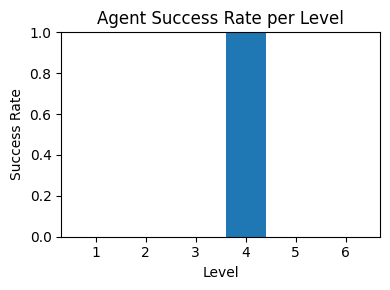

In [7]:
# Evaluate all levels with PPO
model_actions_results = evaluate_levels_with_ppo(PPO_MODEL_PATH, see_through_walls=True)
bar_plot_levels_success_rate(model_actions_results)

In [49]:
# Run level with PPO
run_model_on_level(model_path=PPO_MODEL_PATH, level_id=1, see_through_walls=True)

---

## RecurrentPPO

### Training

In [ ]:
n_envs = 8
n_timesteps = 5_000
freq = 100
eval_freq = max(freq // n_envs, 1)

save_dir = Path("../../models/")
save_dir.mkdir(parents=True, exist_ok=True)

env = ProceduralLevel(difficulty=1000, max_steps=200)
optimiser = EnvOptimiser(
    env=env, n_envs=n_envs, wrapper_cls=[OneHotPartialObsWrapper, ImgObsWrapper], save_dir=save_dir
)
vec_env_train = optimiser.build_vec_env()
policy_kwargs = {
    "features_extractor_class": MinigridFeaturesExtractor,
    "features_extractor_kwargs": {"features_dim": 128},
    "normalize_images": False,
}
model_dir = optimiser.file_path.parent
callback = CustomCallback(check_freq=eval_freq, save_dir=model_dir, verbose=0)
model = RecurrentPPO(policy="CnnLstmPolicy", env=vec_env_train, policy_kwargs=policy_kwargs)
model.learn(total_timesteps=n_timesteps, callback=callback, progress_bar=True)

Output()

### Plots

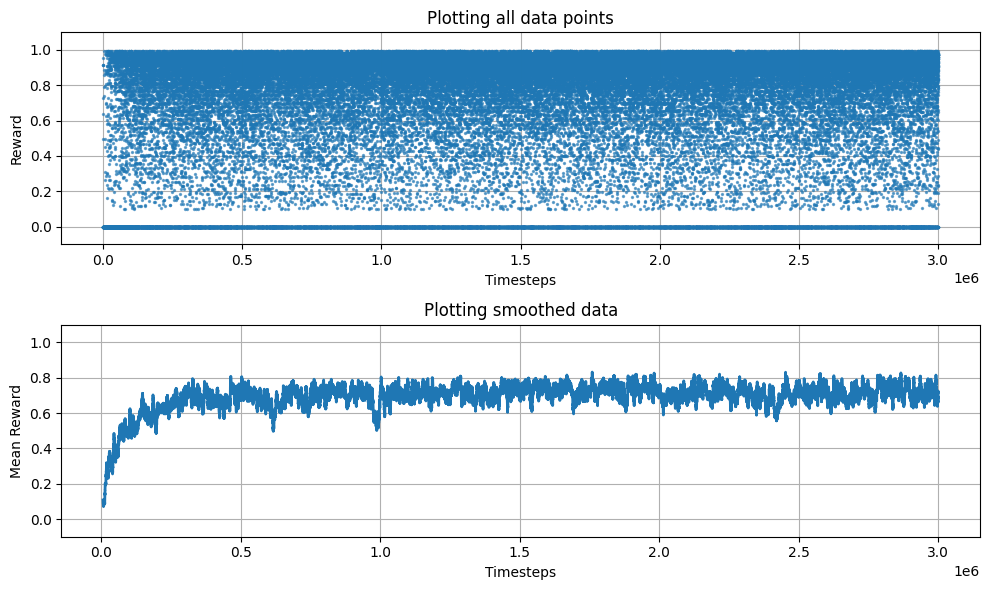

In [ ]:
plot_training_results(log_dir=RECURRENT_PPO_MODEL_PATH_2.parent, window_size=100)

### Testing

Running level 1 with RecurrentPPO model...
Running level 2 with RecurrentPPO model...
Running level 3 with RecurrentPPO model...
Running level 4 with RecurrentPPO model...
Running level 5 with RecurrentPPO model...
Running level 6 with RecurrentPPO model...


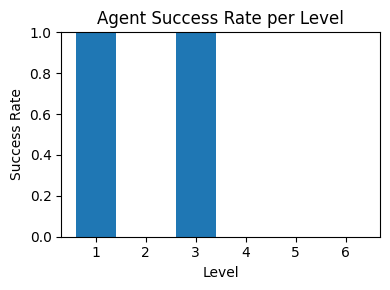

In [ ]:
# Evaluate all levels with RecurrentPPO
model_actions_results = evaluate_levels_with_recurrent_ppo(RECURRENT_PPO_MODEL_PATH_2)
bar_plot_levels_success_rate(model_actions_results)

In [ ]:
# Run procedural level with RecurrentPPO
run_model_on_procedural(model_path=RECURRENT_PPO_MODEL_PATH_2, use_recurrent=True)

In [ ]:
# Run level with PPO
run_model_on_level(model_path=RECURRENT_PPO_MODEL_PATH_2, level_id=2, use_recurrent=True)